# 1. Import

In [238]:
# Data Handling
import pandas as pd
import pandas.api.types
import torch
import numpy as np
import pickle
from typing import List, Optional

# Machine Learning
from sklearn.cluster import KMeans
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Metrics
from sklearn.metrics import roc_auc_score

# Visualization
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.widgets import Slider

# 2. Configuration

In [239]:
class Configuration:
    
    label_names = [
        'Left Infraclinoid Internal Carotid Artery',
        'Right Infraclinoid Internal Carotid Artery',
        'Left Supraclinoid Internal Carotid Artery',
        'Right Supraclinoid Internal Carotid Artery',
        'Left Middle Cerebral Artery',
        'Right Middle Cerebral Artery',
        'Anterior Communicating Artery',
        'Left Anterior Cerebral Artery',
        'Right Anterior Cerebral Artery',
        'Left Posterior Communicating Artery',
        'Right Posterior Communicating Artery',
        'Basilar Tip',
        'Other Posterior Circulation',
        'Aneurysm Present'
    ]
    
CFG = Configuration()

# 3. Load

In [240]:
train_df = pd.read_csv('../train.csv')
swin_df = pd.read_csv('../results/shash/swin_s_predicted_df.csv')
effi_df = pd.read_csv('../results/shash/efficientnetv2_s_predicted_df.csv')
conv_df = pd.read_csv('../results/shash/convnext_s_predicted_df.csv')

In [241]:
scaled_swin_df = swin_df.copy()
scaled_effi_df = effi_df.copy()
scaled_conv_df = conv_df.copy()

minmax_scaler = MinMaxScaler()
scaled_swin_df[CFG.label_names] = minmax_scaler.fit_transform(swin_df[CFG.label_names])
scaled_effi_df[CFG.label_names] = minmax_scaler.fit_transform(effi_df[CFG.label_names])
scaled_conv_df[CFG.label_names] = minmax_scaler.fit_transform(conv_df[CFG.label_names])

In [242]:
train_df

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4343,1.2.826.0.1.3680043.8.498.99915610493694667606...,62,Female,MRI T1post,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4344,1.2.826.0.1.3680043.8.498.99920680741054836990...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4345,1.2.826.0.1.3680043.8.498.99953513260518059135...,44,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4346,1.2.826.0.1.3680043.8.498.99982144859397209076...,58,Female,MRI T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [243]:
swin_df

,SeriesInstanceUID,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.96155132589464464482...,0.085999,0.084412,0.185669,0.157104,0.105225,0.139771,0.122803,0.070129,0.071533,0.103516,0.076416,0.093262,0.099121,0.506836
1,1.2.826.0.1.3680043.8.498.41711215539877472420...,0.086548,0.084167,0.189697,0.154053,0.104858,0.140137,0.121948,0.076233,0.077026,0.107666,0.074097,0.097046,0.102295,0.493652
2,1.2.826.0.1.3680043.8.498.86837346700151751310...,0.083618,0.087097,0.192017,0.146973,0.104980,0.139648,0.119873,0.080566,0.084473,0.108215,0.071899,0.096008,0.107178,0.465576
3,1.2.826.0.1.3680043.8.498.93188368164507061784...,0.094360,0.106079,0.195801,0.184082,0.116333,0.159912,0.134033,0.068420,0.068665,0.103210,0.093506,0.096008,0.110107,0.540527
4,1.2.826.0.1.3680043.8.498.10775557483309974755...,0.059540,0.055298,0.090393,0.087708,0.094666,0.079590,0.158813,0.043518,0.040955,0.037598,0.072632,0.061188,0.080505,0.362061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4343,1.2.826.0.1.3680043.8.498.35703270667185048293...,0.089478,0.092773,0.187622,0.166382,0.110474,0.145508,0.125610,0.065125,0.066101,0.099609,0.082275,0.091370,0.101562,0.528320
4344,1.2.826.0.1.3680043.8.498.58611233316672173480...,0.086487,0.084167,0.189697,0.154053,0.104858,0.140137,0.122009,0.076233,0.077087,0.107727,0.073975,0.097046,0.102173,0.493652
4345,1.2.826.0.1.3680043.8.498.39652515973580028003...,0.085876,0.085632,0.192139,0.151733,0.105835,0.139648,0.121948,0.080078,0.081848,0.109131,0.073425,0.097290,0.105225,0.479492
4346,1.2.826.0.1.3680043.8.498.13349122544213415242...,0.066528,0.066101,0.103027,0.107117,0.102295,0.098267,0.178101,0.050598,0.053894,0.047333,0.089661,0.075745,0.089905,0.391602


In [244]:
scaled_swin_df.describe()

,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
count,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000
mean,0.644321,0.545544,0.674740,0.558313,0.705877,0.546693,0.274844,0.659372,0.609374,0.725488,0.539814,0.736751,0.718627,0.621628
std,0.241550,0.213899,0.353030,0.235676,0.142961,0.260537,0.286447,0.272996,0.216082,0.344796,0.170352,0.214172,0.194623,0.303673
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.381666,0.350274,0.206145,0.322019,0.653285,0.287584,0.069298,0.364544,0.445389,0.274512,0.434416,0.586207,0.567598,0.284730
50%,0.765129,0.582486,0.881070,0.642298,0.705596,0.656532,0.119298,0.730337,0.647700,0.921129,0.456077,0.834846,0.792179,0.748565
75%,0.774715,0.643471,0.894945,0.696258,0.763990,0.667793,0.529825,0.888889,0.768040,0.979740,0.642599,0.889292,0.850279,0.871412
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [245]:
effi_df.head()

,SeriesInstanceUID,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.96155132589464464482...,0.002087,0.001063,0.005344,0.006691,0.003576,0.003860,0.006767,0.000266,0.001377,0.000608,0.000527,0.001777,0.002689,0.020813
1,1.2.826.0.1.3680043.8.498.41711215539877472420...,0.020508,0.020203,0.063232,0.055176,0.046539,0.054047,0.089233,0.011169,0.021790,0.011848,0.026672,0.025589,0.033630,0.178467
2,1.2.826.0.1.3680043.8.498.86837346700151751310...,0.009796,0.008751,0.037018,0.021515,0.021301,0.022705,0.039520,0.003553,0.007240,0.006489,0.006634,0.016876,0.020813,0.118103
3,1.2.826.0.1.3680043.8.498.93188368164507061784...,0.028534,0.060913,0.125366,0.126587,0.052856,0.122131,0.116211,0.032196,0.019577,0.039551,0.043762,0.037476,0.044128,0.458008
4,1.2.826.0.1.3680043.8.498.10775557483309974755...,0.007053,0.004948,0.024246,0.023422,0.012192,0.013580,0.023087,0.001179,0.004223,0.002701,0.003166,0.006554,0.009560,0.066223


In [246]:
scaled_effi_df.describe()

,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
count,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000
mean,0.288053,0.331227,0.419082,0.334112,0.303198,0.383986,0.365492,0.242033,0.325032,0.257271,0.268742,0.277176,0.310734,0.430355
std,0.207660,0.253629,0.257105,0.212830,0.234204,0.258591,0.264118,0.205681,0.248035,0.228038,0.234924,0.201284,0.229117,0.301277
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.105077,0.104254,0.169169,0.130446,0.100155,0.137485,0.129421,0.058664,0.103210,0.055491,0.063125,0.100815,0.115442,0.140696
50%,0.258546,0.269650,0.443489,0.349529,0.222649,0.386379,0.285288,0.192836,0.242933,0.171845,0.183604,0.230532,0.254358,0.435638
75%,0.460992,0.569756,0.645023,0.479021,0.490773,0.602624,0.600475,0.417094,0.541906,0.429392,0.463389,0.455734,0.514193,0.696902
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [247]:
conv_df.head()

,SeriesInstanceUID,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.96155132589464464482...,0.025665,0.026855,0.079895,0.070435,0.058929,0.078430,0.103027,0.013954,0.020538,0.026962,0.032532,0.023956,0.035065,0.454102
1,1.2.826.0.1.3680043.8.498.41711215539877472420...,0.025650,0.026917,0.079895,0.070435,0.058929,0.078369,0.103027,0.013901,0.020569,0.026917,0.032532,0.023911,0.035065,0.454102
2,1.2.826.0.1.3680043.8.498.86837346700151751310...,0.025558,0.026855,0.079773,0.070435,0.058990,0.078369,0.103027,0.013901,0.020523,0.026855,0.032532,0.023911,0.035156,0.454102
3,1.2.826.0.1.3680043.8.498.93188368164507061784...,0.025742,0.026855,0.080078,0.070435,0.058777,0.078491,0.103027,0.013954,0.020523,0.027069,0.032471,0.024002,0.035034,0.454102
4,1.2.826.0.1.3680043.8.498.10775557483309974755...,0.025375,0.026672,0.079773,0.070435,0.058655,0.077942,0.102661,0.013794,0.020416,0.026703,0.032227,0.023819,0.035004,0.451416


In [248]:
scaled_conv_df.describe()

,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
count,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000
mean,0.602877,0.599615,0.559683,0.662244,0.603994,0.658526,0.654554,0.648625,0.591611,0.563984,0.684956,0.580902,0.600949,0.611611
std,0.223217,0.192537,0.155264,0.145636,0.206521,0.325474,0.199741,0.212679,0.190534,0.203058,0.188794,0.201401,0.195719,0.265132
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.435897,0.489362,0.444444,0.625000,0.466667,0.272727,0.571429,0.481481,0.470588,0.425926,0.562500,0.428571,0.463415,0.333333
50%,0.692308,0.638298,0.500000,0.625000,0.583333,0.818182,0.714286,0.777778,0.617647,0.583333,0.750000,0.571429,0.585366,0.714286
75%,0.769231,0.702128,0.666667,0.750000,0.750000,1.000000,0.857143,0.777778,0.735294,0.740741,0.812500,0.714286,0.731707,0.809524
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 4. Analysis

## 4.1 Part-by-Part

In [249]:
label_df_list = []

for i, label_name in enumerate(CFG.label_names):
    temp_df = pd.DataFrame()
    temp_df['SeriesInstanceUID'] = train_df['SeriesInstanceUID']
    temp_df[f'swin_s'] = swin_df[label_name]
    temp_df[f'effi_s'] = effi_df[label_name]
    temp_df[f'conv_s'] = conv_df[label_name]
    temp_df[f'train'] = train_df[label_name]
    label_df_list.append(temp_df)

In [250]:
label_df_list[0].head()

,SeriesInstanceUID,swin_s,effi_s,conv_s,train
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,0.085999,0.002087,0.025665,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,0.086548,0.020508,0.025650,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,0.083618,0.009796,0.025558,0
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,0.094360,0.028534,0.025742,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,0.059540,0.007053,0.025375,0


In [251]:
label_df_list[0].describe()

,swin_s,effi_s,conv_s,train
count,4348.000000,4348.000000,4348.000000,4348.000000
mean,0.080334,0.035558,0.025566,0.017939
std,0.012303,0.024949,0.000133,0.132746
min,0.047516,0.000950,0.025208,0.000000
25%,0.066956,0.013575,0.025467,0.000000
50%,0.086487,0.032013,0.025620,0.000000
75%,0.086975,0.056335,0.025665,0.000000
max,0.098450,0.121094,0.025803,1.000000


In [252]:
df = label_df_list[1]  # 例：2番目のラベル

fig = go.Figure(data=[go.Scatter3d(
    x=df['swin_s'],
    y=df['effi_s'],
    z=df['conv_s'],
    mode='markers',
    marker=dict(
        size=2,
        color=df['train'],  # ラベルで色分け
        # colorscale='Viridis',
        opacity=0.7
    ),
    text=df['SeriesInstanceUID']
)])

fig.update_layout(
    scene = dict(
        xaxis_title='swin_s',
        yaxis_title='effi_s',
        zaxis_title='conv_s'
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    title="3D Interactive Scatter Plot"
)

fig.show()

Explained variance ratio: [0.77796284 0.22203389]


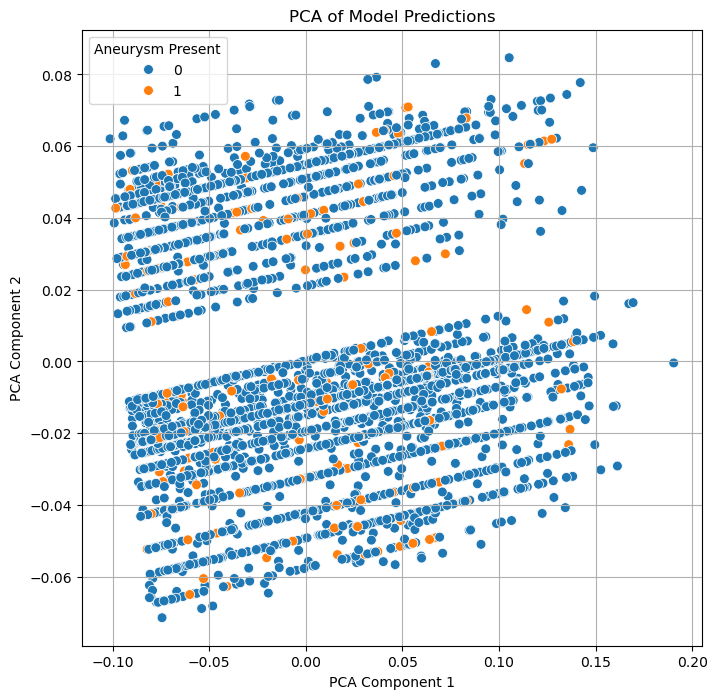

In [253]:
# PCA

# 1番目のラベルで実施
df = label_df_list[3]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[['swin_s', 'effi_s', 'conv_s']])
df['pca_1'] = pca_result[:, 0]
df['pca_2'] = pca_result[:, 1]
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
plt.figure(figsize=(8, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='train', data=df, s=50)
plt.title('PCA of Model Predictions')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Aneurysm Present')
plt.grid()
plt.show()

Text(0.5, 1.0, 'Swin vs EfficientNetV2 Predictions')

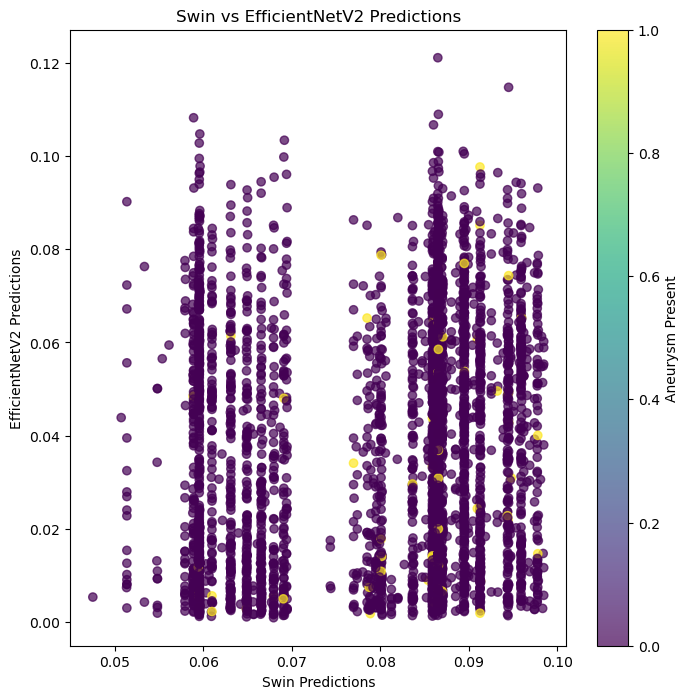

In [254]:
# Swin x EfficientNetV2
plt.figure(figsize=(8, 8))
plt.scatter(swin_df['Left Infraclinoid Internal Carotid Artery'],
            effi_df['Left Infraclinoid Internal Carotid Artery'],
            c=train_df['Left Infraclinoid Internal Carotid Artery'],
            alpha=0.7)
plt.colorbar(label='Aneurysm Present')
plt.xlabel('Swin Predictions')
plt.ylabel('EfficientNetV2 Predictions')
plt.title('Swin vs EfficientNetV2 Predictions')

Text(0.5, 1.0, 'Swin vs ConvNext Predictions')

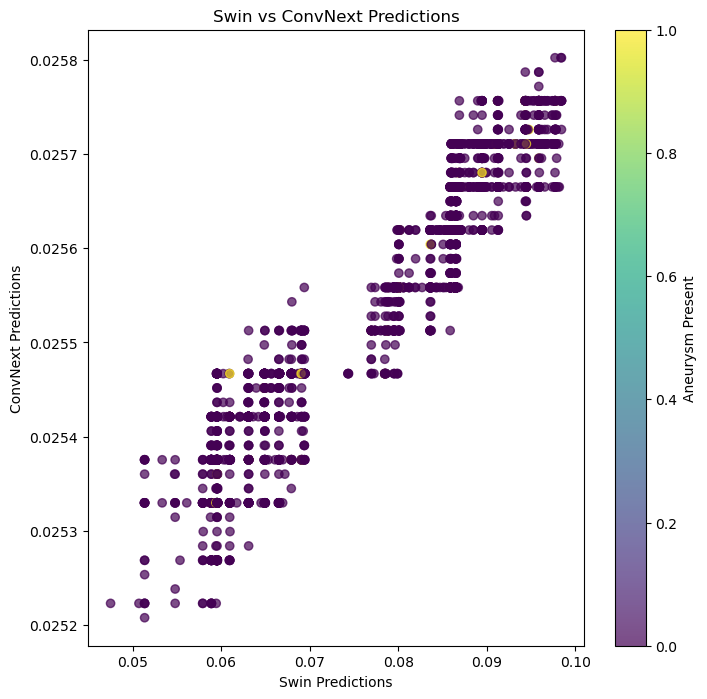

In [255]:
# Swing x ConvNext
plt.figure(figsize=(8, 8))
plt.scatter(swin_df['Left Infraclinoid Internal Carotid Artery'],
            conv_df['Left Infraclinoid Internal Carotid Artery'],
            c=train_df['Left Infraclinoid Internal Carotid Artery'],
            alpha=0.7)
plt.colorbar(label='Aneurysm Present')
plt.xlabel('Swin Predictions')
plt.ylabel('ConvNext Predictions')
plt.title('Swin vs ConvNext Predictions')

Text(0.5, 1.0, 'EfficientNetV2 vs ConvNext Predictions')

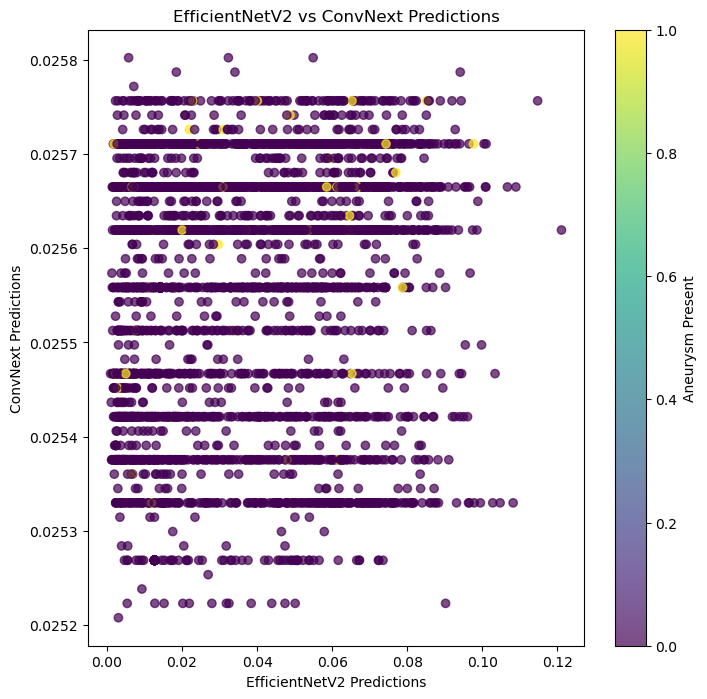

In [256]:
# EfficientNetV2 x ConvNext
plt.figure(figsize=(8, 8))
plt.scatter(effi_df['Left Infraclinoid Internal Carotid Artery'],
            conv_df['Left Infraclinoid Internal Carotid Artery'],
            c=train_df['Left Infraclinoid Internal Carotid Artery'],
            alpha=0.7)
plt.colorbar(label='Aneurysm Present')
plt.xlabel('EfficientNetV2 Predictions')
plt.ylabel('ConvNext Predictions')
plt.title('EfficientNetV2 vs ConvNext Predictions')

## 4.2 Analysis by Model

In [257]:
swin_df.describe()

,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
count,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000,4348.000000
mean,0.080334,0.081345,0.162575,0.142273,0.104872,0.128230,0.136311,0.065012,0.065982,0.086159,0.079137,0.086664,0.098155,0.466415
std,0.012303,0.016698,0.043482,0.033056,0.007173,0.028242,0.019931,0.013347,0.015124,0.029084,0.008640,0.014405,0.010632,0.064575
min,0.047516,0.038757,0.079468,0.063965,0.069458,0.068970,0.117188,0.032776,0.023331,0.024963,0.051758,0.037109,0.058899,0.334229
25%,0.066956,0.066101,0.104858,0.109131,0.102234,0.100143,0.122009,0.050598,0.054504,0.048119,0.073792,0.076538,0.089905,0.394775
50%,0.086487,0.084229,0.187988,0.154053,0.104858,0.140137,0.125488,0.068481,0.068665,0.102661,0.074890,0.093262,0.102173,0.493408
75%,0.086975,0.088989,0.189697,0.161621,0.107788,0.141357,0.154053,0.076233,0.077087,0.107605,0.084351,0.096924,0.105347,0.519531
max,0.098450,0.116821,0.202637,0.204224,0.119629,0.177368,0.186768,0.081665,0.093323,0.109314,0.102478,0.104370,0.113525,0.546875


In [258]:
swin_df

,SeriesInstanceUID,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.96155132589464464482...,0.085999,0.084412,0.185669,0.157104,0.105225,0.139771,0.122803,0.070129,0.071533,0.103516,0.076416,0.093262,0.099121,0.506836
1,1.2.826.0.1.3680043.8.498.41711215539877472420...,0.086548,0.084167,0.189697,0.154053,0.104858,0.140137,0.121948,0.076233,0.077026,0.107666,0.074097,0.097046,0.102295,0.493652
2,1.2.826.0.1.3680043.8.498.86837346700151751310...,0.083618,0.087097,0.192017,0.146973,0.104980,0.139648,0.119873,0.080566,0.084473,0.108215,0.071899,0.096008,0.107178,0.465576
3,1.2.826.0.1.3680043.8.498.93188368164507061784...,0.094360,0.106079,0.195801,0.184082,0.116333,0.159912,0.134033,0.068420,0.068665,0.103210,0.093506,0.096008,0.110107,0.540527
4,1.2.826.0.1.3680043.8.498.10775557483309974755...,0.059540,0.055298,0.090393,0.087708,0.094666,0.079590,0.158813,0.043518,0.040955,0.037598,0.072632,0.061188,0.080505,0.362061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4343,1.2.826.0.1.3680043.8.498.35703270667185048293...,0.089478,0.092773,0.187622,0.166382,0.110474,0.145508,0.125610,0.065125,0.066101,0.099609,0.082275,0.091370,0.101562,0.528320
4344,1.2.826.0.1.3680043.8.498.58611233316672173480...,0.086487,0.084167,0.189697,0.154053,0.104858,0.140137,0.122009,0.076233,0.077087,0.107727,0.073975,0.097046,0.102173,0.493652
4345,1.2.826.0.1.3680043.8.498.39652515973580028003...,0.085876,0.085632,0.192139,0.151733,0.105835,0.139648,0.121948,0.080078,0.081848,0.109131,0.073425,0.097290,0.105225,0.479492
4346,1.2.826.0.1.3680043.8.498.13349122544213415242...,0.066528,0.066101,0.103027,0.107117,0.102295,0.098267,0.178101,0.050598,0.053894,0.047333,0.089661,0.075745,0.089905,0.391602


In [259]:
swin_df.sort_values('SeriesInstanceUID', inplace=True)
effi_df.sort_values('SeriesInstanceUID', inplace=True)
conv_df.sort_values('SeriesInstanceUID', inplace=True)

scaled_swin_df.sort_values('SeriesInstanceUID', inplace=True)
scaled_effi_df.sort_values('SeriesInstanceUID', inplace=True)
scaled_conv_df.sort_values('SeriesInstanceUID', inplace=True)

train_df.sort_values('SeriesInstanceUID', inplace=True)

In [260]:
sum((swin_df[label_name] > 0.5) & (train_df[label_name] > 0.5))

627

In [261]:
all_aucs = {}
all_scaled_aucs = {}

for label_name in CFG.label_names:
    
    aucs = {
        'swin': roc_auc_score(train_df[label_name], swin_df[label_name]),
        'effi': roc_auc_score(train_df[label_name], effi_df[label_name]),
        'conv': roc_auc_score(train_df[label_name], conv_df[label_name])
    }
    
    all_aucs[label_name] = aucs
    
    scaled_aucs = {
        'swin': roc_auc_score(train_df[label_name], scaled_swin_df[label_name]),
        'effi': roc_auc_score(train_df[label_name], scaled_effi_df[label_name]),
        'conv': roc_auc_score(train_df[label_name], scaled_conv_df[label_name])
    }
    
    all_scaled_aucs[label_name] = scaled_aucs
    
    print(f'Label: {label_name}')
    print(f'  AUCs: {aucs}')
    print(f'  Scaled AUCs: {scaled_aucs}')
    print('==================================================================')

Label: Left Infraclinoid Internal Carotid Artery
  AUCs: {'swin': 0.6044661622530475, 'effi': 0.7159821053263675, 'conv': 0.5889089053023479}
  Scaled AUCs: {'swin': 0.6044661622530475, 'effi': 0.7159821053263675, 'conv': 0.5889089053023479}
Label: Right Infraclinoid Internal Carotid Artery
  AUCs: {'swin': 0.5930156062424969, 'effi': 0.7159747899159664, 'conv': 0.5499555822328932}
  Scaled AUCs: {'swin': 0.5930156062424969, 'effi': 0.7159747899159664, 'conv': 0.5499555822328932}
Label: Left Supraclinoid Internal Carotid Artery
  AUCs: {'swin': 0.6025776401953329, 'effi': 0.7397100841062945, 'conv': 0.5831894960015102}
  Scaled AUCs: {'swin': 0.6025776401953329, 'effi': 0.7397100841062945, 'conv': 0.5831894960015102}
Label: Right Supraclinoid Internal Carotid Artery
  AUCs: {'swin': 0.5624865319283087, 'effi': 0.7491262934891241, 'conv': 0.5105895623442027}
  Scaled AUCs: {'swin': 0.5624865319283087, 'effi': 0.7491262934891241, 'conv': 0.5105895623442027}
Label: Left Middle Cerebral Ar

In [262]:
magnifications = {}
for label_name, aucs in all_aucs.items():
    
    swin_acc = aucs['swin']
    effi_acc = aucs['effi']
    conv_acc = aucs['conv']
    total_acc = swin_acc + effi_acc + conv_acc
    
    swin_mag = swin_acc / total_acc
    effi_mag = effi_acc / total_acc
    conv_mag = conv_acc / total_acc
    
    magnifications[label_name] = [swin_mag, effi_mag, conv_mag]

for label_name, mags in magnifications.items():
    print(f'Label: {label_name}')
    print(f'  Magnifications: Swin: {mags[0]:.4f}, EfficientNetV2: {mags[1]:.4f}, ConvNext: {mags[2]:.4f}')
    print('==================================================================')

Label: Left Infraclinoid Internal Carotid Artery
  Magnifications: Swin: 0.3166, EfficientNetV2: 0.3750, ConvNext: 0.3084
Label: Right Infraclinoid Internal Carotid Artery
  Magnifications: Swin: 0.3190, EfficientNetV2: 0.3852, ConvNext: 0.2958
Label: Left Supraclinoid Internal Carotid Artery
  Magnifications: Swin: 0.3129, EfficientNetV2: 0.3842, ConvNext: 0.3029
Label: Right Supraclinoid Internal Carotid Artery
  Magnifications: Swin: 0.3087, EfficientNetV2: 0.4111, ConvNext: 0.2802
Label: Left Middle Cerebral Artery
  Magnifications: Swin: 0.2811, EfficientNetV2: 0.4017, ConvNext: 0.3172
Label: Right Middle Cerebral Artery
  Magnifications: Swin: 0.3088, EfficientNetV2: 0.3898, ConvNext: 0.3014
Label: Anterior Communicating Artery
  Magnifications: Swin: 0.2959, EfficientNetV2: 0.4179, ConvNext: 0.2862
Label: Left Anterior Cerebral Artery
  Magnifications: Swin: 0.2563, EfficientNetV2: 0.4254, ConvNext: 0.3183
Label: Right Anterior Cerebral Artery
  Magnifications: Swin: 0.2752, Eff

In [263]:
magnifications

{'Left Infraclinoid Internal Carotid Artery': [0.316580978581779,
  0.37498594579124606,
  0.308433075626975],
 'Right Infraclinoid Internal Carotid Artery': [0.31900636873572,
  0.3851509394240369,
  0.29584269184024303],
 'Left Supraclinoid Internal Carotid Artery': [0.31294976322829005,
  0.38416974052273556,
  0.30288049624897445],
 'Right Supraclinoid Internal Carotid Artery': [0.3086849933388893,
  0.4111103676081442,
  0.28020463905296644],
 'Left Middle Cerebral Artery': [0.2810553380697498,
  0.40169739314214525,
  0.317247268788105],
 'Right Middle Cerebral Artery': [0.30882184304369487,
  0.3898024606194266,
  0.3013756963368785],
 'Anterior Communicating Artery': [0.29587468599020966,
  0.41794102286783474,
  0.2861842911419555],
 'Left Anterior Cerebral Artery': [0.2562711143399343,
  0.4253930064057765,
  0.31833587925428913],
 'Right Anterior Cerebral Artery': [0.27522878434659004,
  0.42434432130976,
  0.30042689434364994],
 'Left Posterior Communicating Artery': [0.274

In [264]:
with open('../ensemble_magnifications.pkl', 'wb') as f:
    pickle.dump(magnifications, f)

In [200]:
scaled_magnifications = magnifications

## 3.3 Ensemble

In [201]:
class ParticipantVisibleError(Exception):
    pass

def score(
    solution: pd.DataFrame,
    submission: pd.DataFrame,
    row_id_column_name: str,
    class_weights: Optional[List[float]] = None,
) -> float:
    """
    Calculates the weighted macro-average AUCROC score.

    This metric generalizes the `roc_auc_score` with `average='macro'` by allowing user-defined class weights.

    Parameters
    ----------
    solution : pd.DataFrame
        DataFrame containing the true labels.
    submission : pd.DataFrame
        DataFrame containing the predicted scores.
    row_id_column_name : str
        The name of the column containing the row IDs.
    class_weights : Optional[List[float]], default=None
        A list of weights for each class. If None, all classes are weighted equally.

    Returns
    -------
    float
        The weighted multi-label AUC score.

    Examples
    --------
    >>> # Test for perfect predictions.
    >>> solution = pd.DataFrame({'id': [1, 2, 3], 'cat': [1, 0, 1], 'dog': [0, 1, 1]})
    >>> submission = pd.DataFrame({'id': [1, 2, 3], 'cat': [0.9, 0.2, 0.8], 'dog': [0.1, 0.7, 0.6]})
    >>> score(solution.copy(), submission.copy(), 'id')
    1.0

    >>> score(solution.copy(), submission.copy(), 'id', class_weights=[0.25, 0.75])
    1.0

    >>> # Test weighting.
    >>> solution = pd.DataFrame({'id': [1, 2, 3, 4], 'A': [0, 0, 1, 1], 'B': [0, 0, 1, 1]})
    >>> submission = pd.DataFrame({'id': [1, 2, 3, 4], 'A': [0.1, 0.2, 0.8, 0.9], 'B': [0.8, 0.2, 0.1, 0.9]})
    >>> # Here, the AUC for class 'A' is 1.0 and for class 'B' is 0.5.
    >>> # The unweighted macro-average is (1.0 + 0.5) / 2 = 0.75.
    >>> score(solution.copy(), submission.copy(), 'id')
    0.75

    >>> # Using weights to prioritize the better-performing class 'A'.
    >>> # The weighted average is (1.0 * 0.75) + (0.5 * 0.25) = 0.875.
    >>> score(solution.copy(), submission.copy(), 'id', class_weights=[3, 1])
    0.875

    >>> # Using weights to prioritize the worse-performing class 'B'.
    >>> # The weighted average is (1.0 * 0.25) + (0.5 * 0.75) = 0.625.
    >>> score(solution.copy(), submission.copy(), 'id', class_weights=[1, 3])
    0.625
    """
    # Per competition requirements, we don't use the row_id_column
    del solution[row_id_column_name]
    del submission[row_id_column_name]

    # Validate that all submission columns are numeric
    for col in submission.columns:
        if not pandas.api.types.is_numeric_dtype(submission[col]):
            raise ParticipantVisibleError(f'Submission column {col} must be numeric.')

    # Validate that the number of columns match
    if len(solution.columns) != len(submission.columns):
        raise ParticipantVisibleError(
            'Submission must have predictions for every class.'
        )

    return float(
        weighted_multilabel_auc(solution.values, submission.values, class_weights)
    )

def weighted_multilabel_auc(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    class_weights: Optional[List[float]] = None,
) -> float:
    """Compute weighted AUC for multilabel classification.

    Parameters:
    -----------
    y_true : np.ndarray of shape (n_samples, n_classes)
        True binary labels (0 or 1) for each class
    y_scores : np.ndarray of shape (n_samples, n_classes)
        Target scores (probability estimates or decision values)
    class_weights : array-like of shape (n_classes,), optional
        Weights for each class. If None, uniform weights are used.
        Weights will be normalized to sum to 1.

    Returns:
    --------
    weighted_auc : float
        The weighted average AUC

    Raises:
    -------
    ValueError
        If any class does not have both positive and negative samples
    """
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    n_classes = y_true.shape[1]

    # Get AUC for each class
    try:
        individual_aucs = roc_auc_score(y_true, y_scores, average=None)
    except ValueError:
        raise ParticipantVisibleError(
            'AUC could not be calculated from given predictions.'
        ) from None

    # Handle weights
    if class_weights is None:  # Uniform weights
        weights_array = np.ones(n_classes)
    else:
        weights_array = np.asarray(class_weights)

    # Check weight dimensions
    if len(weights_array) != n_classes:
        raise ValueError(
            f'Number of weights ({len(weights_array)}) must match '
            f'number of classes ({n_classes})'
        )

    # Check for non-negative weights
    if np.any(weights_array < 0):
        raise ValueError('All class weights must be non-negative')

    # Check that at least one weight is positive
    if np.sum(weights_array) == 0:
        raise ValueError('At least one class weight must be positive')

    # Normalize weights to sum to 1
    weights_array = weights_array / np.sum(weights_array)

    # Compute weighted average
    return np.sum(individual_aucs * weights_array)

In [202]:
class_weights = [1] * 13 + [13]
class_weights

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 13]

In [204]:
swin_df

,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,0.085999,0.084412,0.185669,0.157104,0.105225,0.139771,0.122803,0.070129,0.071533,0.103516,0.076416,0.093262,0.099121,0.506836
1,0.086548,0.084167,0.189697,0.154053,0.104858,0.140137,0.121948,0.076233,0.077026,0.107666,0.074097,0.097046,0.102295,0.493652
2,0.083618,0.087097,0.192017,0.146973,0.104980,0.139648,0.119873,0.080566,0.084473,0.108215,0.071899,0.096008,0.107178,0.465576
3,0.094360,0.106079,0.195801,0.184082,0.116333,0.159912,0.134033,0.068420,0.068665,0.103210,0.093506,0.096008,0.110107,0.540527
4,0.059540,0.055298,0.090393,0.087708,0.094666,0.079590,0.158813,0.043518,0.040955,0.037598,0.072632,0.061188,0.080505,0.362061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4343,0.089478,0.092773,0.187622,0.166382,0.110474,0.145508,0.125610,0.065125,0.066101,0.099609,0.082275,0.091370,0.101562,0.528320
4344,0.086487,0.084167,0.189697,0.154053,0.104858,0.140137,0.122009,0.076233,0.077087,0.107727,0.073975,0.097046,0.102173,0.493652
4345,0.085876,0.085632,0.192139,0.151733,0.105835,0.139648,0.121948,0.080078,0.081848,0.109131,0.073425,0.097290,0.105225,0.479492
4346,0.066528,0.066101,0.103027,0.107117,0.102295,0.098267,0.178101,0.050598,0.053894,0.047333,0.089661,0.075745,0.089905,0.391602


In [203]:
swin_comp_auc = score(
    solution=train_df,
    submission=swin_df,
    row_id_column_name='SeriesInstanceUID',
    class_weights=class_weights
)
swin_comp_auc

ParticipantVisibleError: Submission must have predictions for every class.